# NBA Prediction Market Bias: Does Pre-Game Media Coverage Skew Market Prices?

**ICS 604: Applied Data Science — Final Project**  
**Author:** Nicholas Fairhart

---

## Research Question

Do NBA prediction markets exhibit systematic pricing bias correlated with pre-game media attention disparities?

## Formal Hypotheses

- **H₀ (Null):** Pre-game media coverage disparity has no effect on Kalshi market-implied probabilities — the losing team's overpricing is unrelated to how much media attention it received relative to the winning team.
- **H₁ (Alternative):** Teams receiving disproportionately more pre-game media coverage are systematically overpriced in prediction markets. The probability the market assigns to the eventual loser is higher when the loser had greater media coverage, independent of objective team quality.

## Analytical Plan

1. Data preprocessing & merging (three sources)
2. Exploratory data analysis
3. Hypothesis testing: bootstrap CI, permutation test, Welch t-test
4. Regression: OLS (bounded-variable check) + logistic regression on binary game outcome
5. Conclusions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.formula.api as smf

np.random.seed(42)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

## Section 0: Data Preprocessing & Merging

Three datasets are combined:

| Source | File | Contents |
|--------|------|----------|
| Kalshi + GDELT (pre-aggregated) | `gdelt_nba_games.csv` | 1,339 games; market-implied probabilities, pre-game article counts, media disparity metrics |
| Pregame rolling team features | `nba_pregame_features.csv` | One row per game; trailing team form features (`t1_`, `t2_`) and differentials (`diff_`) built pre-tipoff |
| GDELT raw per-team | `gdelt_nba_coverage.csv` | One row per team-game; article count and sentiment — used to validate the aggregation in `gdelt_nba_games.csv` |

**GDELT preprocessing note:** The raw `gdelt_nba_coverage.csv` contains one row per team per game window. Duplicate article entries (same URL captured multiple times) were identified and dropped before aggregation. Article counts were summed and sentiment scores were averaged per team-game to produce the per-game metrics in `gdelt_nba_games.csv`.

**Merge strategy:** `nba_pregame_features.csv` is joined to each game row by `event_ticker`. This replaces the Basketball-Reference Net Rating controls with pregame rolling form controls learned in class-style regression workflows.

In [2]:
# Load the three data sources
games_df = pd.read_csv('gdelt_nba_games.csv', parse_dates=['game_date'])
pregame_df = pd.read_csv('nba_pregame_features.csv', parse_dates=['game_date'])
coverage_df = pd.read_csv('gdelt_nba_coverage.csv')

print('gdelt_nba_games.csv:       ', games_df.shape)
print('nba_pregame_features.csv:  ', pregame_df.shape)
print('gdelt_nba_coverage.csv:    ', coverage_df.shape)
print()
print('Games date range:', games_df['game_date'].min().date(), '→', games_df['game_date'].max().date())

gdelt_nba_games.csv:        (1339, 24)
nba_pregame_features.csv:   (1194, 48)
gdelt_nba_coverage.csv:     (2678, 10)

Games date range: 2025-04-15 → 2026-04-21


In [3]:
# --- Step 1: Join pregame rolling features onto each game row (ICS 604 style: merge + feature engineering) ---
merge_cols = [
    'event_ticker', 'diff_roll_win_pct', 'diff_roll_pm', 'diff_rest_days',
    't1_roll_win_pct', 't2_roll_win_pct', 'team1_won'
]

pregame_merge = pregame_df[merge_cols].copy()
games_df = games_df.merge(pregame_merge, on='event_ticker', how='left', suffixes=('', '_pregame'))

print('After pregame-feature join:')
print('  diff_roll_win_pct null count:', games_df['diff_roll_win_pct'].isnull().sum())
print('  diff_roll_pm      null count:', games_df['diff_roll_pm'].isnull().sum())

# --- Step 2: Derive analysis columns ---
# team1 = away team, team2 = home team (encoded in Kalshi ticker)
# winner_is_home: 1 if the home team (team2) won
games_df['winner_is_home'] = (games_df['winner'] == games_df['team2']).astype(int)

# media_disparity_loser: positive = losing team had MORE pre-game coverage
# media_disparity_t1 is positive when team1 has more articles
games_df['media_disparity_loser'] = np.where(
    games_df['winner'] == games_df['team1'],
    -games_df['media_disparity_t1'],   # team1 won -> loser is team2 -> flip sign
    games_df['media_disparity_t1']     # team2 won -> loser is team1 -> keep sign
)

# team1_won and team1_implied_prob (for logistic regression)
games_df['team1_won'] = (games_df['winner'] == games_df['team1']).astype(int)
games_df['team1_implied_prob'] = np.where(
    games_df['team1_won'] == 1,
    games_df['winner_implied_prob'],
    games_df['loser_implied_prob']
)

# Convert team1 differential features into winner-advantage controls for OLS
# Positive values mean the eventual winner had stronger pregame form.
games_df['pregame_adv_roll_win_pct'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_roll_win_pct'],
    -games_df['diff_roll_win_pct']
)
games_df['pregame_adv_roll_pm'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_roll_pm'],
    -games_df['diff_roll_pm']
)
games_df['pregame_adv_rest_days'] = np.where(
    games_df['team1_won'] == 1,
    games_df['diff_rest_days'],
    -games_df['diff_rest_days']
)

# --- Step 3: GDELT minimum-coverage filter ---
# Teams with very sparse mentions (<10 articles) produce unstable disparity scores
min_articles = 10
nb_before_filter = len(games_df)
games_df = games_df[
    (games_df['team1_articles'] >= min_articles) &
    (games_df['team2_articles'] >= min_articles)
].copy()
print(f'Rows before coverage filter: {nb_before_filter:,}')
print(f'Rows after coverage filter:  {len(games_df):,}')

# --- Step 4: Drop rows with any remaining nulls in analysis columns ---
analysis_cols = [
    'loser_implied_prob', 'media_disparity_loser', 'winner_is_home',
    'pregame_adv_roll_win_pct', 'pregame_adv_roll_pm',
    'team1_won', 'team1_implied_prob', 'diff_roll_win_pct', 'diff_roll_pm', 'diff_rest_days'
]
nb_before_drop = len(games_df)
dfa = games_df.dropna(subset=analysis_cols).copy()
print(f'Rows after dropping nulls:   {len(dfa):,}  (dropped {nb_before_drop - len(dfa)})')

After pregame-feature join:
  diff_roll_win_pct null count: 193
  diff_roll_pm      null count: 193
Rows before coverage filter: 1,339
Rows after coverage filter:  1,251
Rows after dropping nulls:   1,069  (dropped 182)


## Section 1: Descriptive Statistics

Before testing hypotheses, we examine the distributions of the key variables to understand the data structure.

In [4]:
eda_cols = [
    'loser_implied_prob', 'media_disparity_loser',
    'pregame_adv_roll_win_pct', 'pregame_adv_roll_pm',
    'team1_articles', 'team2_articles'
]
dfa[eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
loser_implied_prob,1069.0000,0.3955,0.2070,0.0218,0.2241,0.3663,0.5478,0.8998
media_disparity_loser,1069.0000,-0.0166,0.1316,-0.4157,-0.1031,-0.0174,0.0720,0.3636
pregame_adv_roll_win_pct,1069.0000,0.3495,0.9532,-2.5350,-0.3007,0.3007,0.9761,3.2104
pregame_adv_roll_pm,1069.0000,0.3771,0.9472,-2.6516,-0.2711,0.3481,1.0855,3.0795
team1_articles,1069.0000,77.1506,34.0873,14.0000,54.0000,70.0000,91.0000,283.0000
team2_articles,1069.0000,74.7203,33.6671,16.0000,52.0000,68.0000,89.0000,295.0000


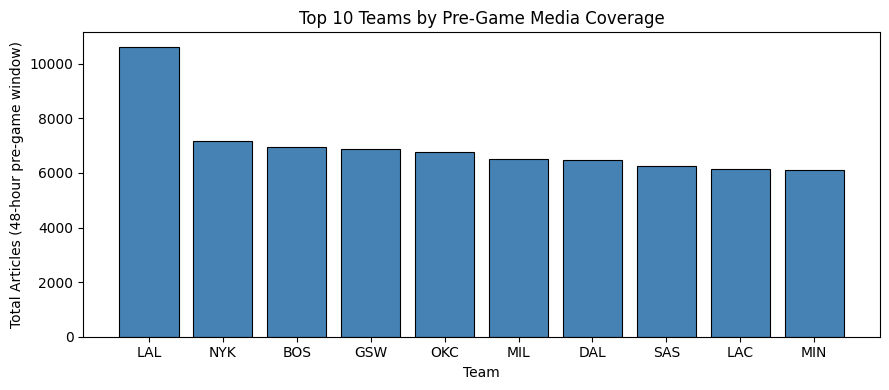

In [5]:
# Total article mentions per team across all games (team1 + team2 appearances)
team1_counts = dfa.groupby('team1')['team1_articles'].sum()
team2_counts = dfa.groupby('team2')['team2_articles'].sum()
total_coverage = (team1_counts.add(team2_counts, fill_value=0)
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(9, 4))
plt.bar(total_coverage.index, total_coverage.values, color='steelblue', edgecolor='black', linewidth=0.8)
plt.xlabel('Team')
plt.ylabel('Total Articles (48-hour pre-game window)')
plt.title('Top 10 Teams by Pre-Game Media Coverage')
plt.tight_layout()
plt.savefig('fig_coverage_by_team.png', dpi=150, bbox_inches='tight')
plt.show()

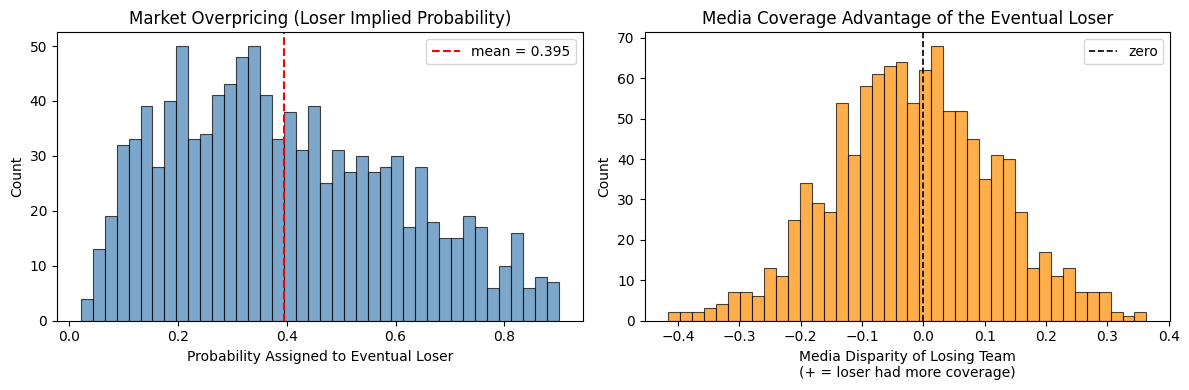

Loser had MORE pre-game coverage: 486 games (45.5%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loser implied probability distribution
axes[0].hist(dfa['loser_implied_prob'], bins=40, edgecolor='black', linewidth=0.8,
             alpha=0.7, color='steelblue')
axes[0].axvline(dfa['loser_implied_prob'].mean(), color='red', linestyle='--',
                label=f"mean = {dfa['loser_implied_prob'].mean():.3f}")
axes[0].set_xlabel('Probability Assigned to Eventual Loser')
axes[0].set_ylabel('Count')
axes[0].set_title('Market Overpricing (Loser Implied Probability)')
axes[0].legend()

# Media disparity of loser distribution
axes[1].hist(dfa['media_disparity_loser'], bins=40, edgecolor='black', linewidth=0.8,
             alpha=0.7, color='darkorange')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2, label='zero')
axes[1].set_xlabel('Media Disparity of Losing Team\n(+ = loser had more coverage)')
axes[1].set_ylabel('Count')
axes[1].set_title('Media Coverage Advantage of the Eventual Loser')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Loser had MORE pre-game coverage: {(dfa['media_disparity_loser'] > 0).sum():,} games "
      f"({(dfa['media_disparity_loser'] > 0).mean()*100:.1f}%)")

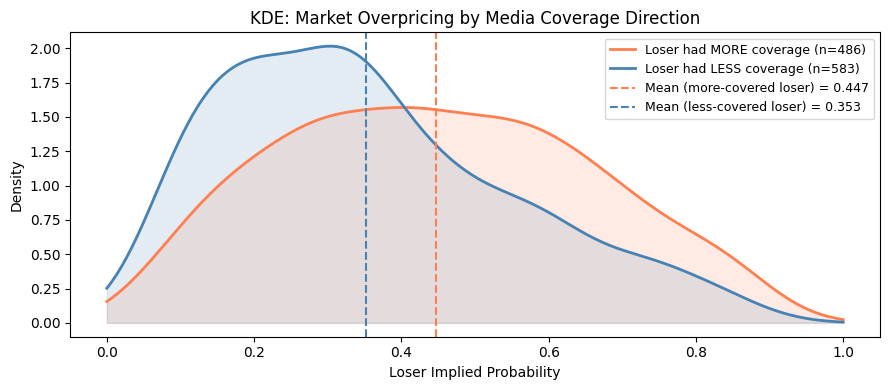

In [7]:
# Gaussian KDE: pricing-error distributions for high-coverage vs low-coverage losers
# Split on SIGNED disparity — positive = loser had more coverage, negative = loser had less
pos_group = dfa[dfa['media_disparity_loser'] > 0]['loser_implied_prob'].dropna()
neg_group = dfa[dfa['media_disparity_loser'] <= 0]['loser_implied_prob'].dropna()

kde_pos = scipy.stats.gaussian_kde(pos_group)
kde_neg = scipy.stats.gaussian_kde(neg_group)
x_vals = np.linspace(0, 1, 300)

plt.figure(figsize=(9, 4))
plt.plot(x_vals, kde_pos(x_vals), color='coral', linewidth=2, label=f'Loser had MORE coverage (n={len(pos_group):,})')
plt.plot(x_vals, kde_neg(x_vals), color='steelblue', linewidth=2, label=f'Loser had LESS coverage (n={len(neg_group):,})')
plt.fill_between(x_vals, kde_pos(x_vals), alpha=0.15, color='coral')
plt.fill_between(x_vals, kde_neg(x_vals), alpha=0.15, color='steelblue')
plt.axvline(pos_group.mean(), color='coral', linestyle='--', linewidth=1.5,
            label=f'Mean (more-covered loser) = {pos_group.mean():.3f}')
plt.axvline(neg_group.mean(), color='steelblue', linestyle='--', linewidth=1.5,
            label=f'Mean (less-covered loser) = {neg_group.mean():.3f}')
plt.xlabel('Loser Implied Probability')
plt.ylabel('Density')
plt.title('KDE: Market Overpricing by Media Coverage Direction')
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_sentiment_dist.png', dpi=150, bbox_inches='tight')
plt.show()

Mean loser implied probability by media disparity tertile:
                   n  mean_implied_prob    std  median_implied_prob
disparity_level                                                    
Low              356             0.3283 0.1838               0.3044
Medium           356             0.4021 0.2090               0.3710
High             357             0.4557 0.2077               0.4421


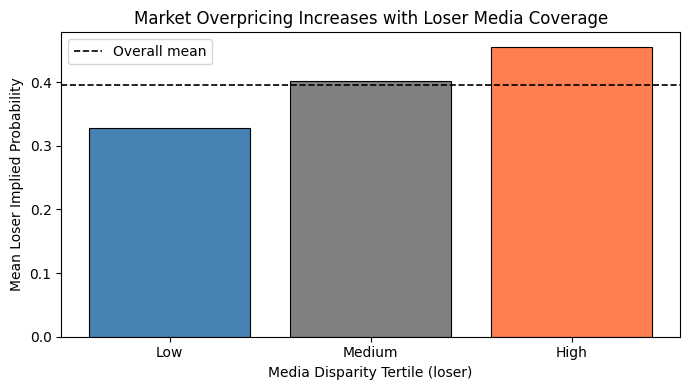

In [8]:
# Stratify by media disparity level (Low / Medium / High tertiles) using GroupBy
dfa['disparity_level'] = pd.qcut(dfa['media_disparity_loser'], q=3,
                                  labels=['Low', 'Medium', 'High'])

group_stats = (dfa.groupby('disparity_level', observed=True)['loser_implied_prob']
               .agg(['count', 'mean', 'std', 'median']))
group_stats.columns = ['n', 'mean_implied_prob', 'std', 'median_implied_prob']
print('Mean loser implied probability by media disparity tertile:')
print(group_stats.round(4))

plt.figure(figsize=(7, 4))
plt.bar(group_stats.index, group_stats['mean_implied_prob'],
        color=['steelblue', 'gray', 'coral'], edgecolor='black', linewidth=0.8)
plt.axhline(dfa['loser_implied_prob'].mean(), color='black', linestyle='--',
            linewidth=1.2, label='Overall mean')
plt.xlabel('Media Disparity Tertile (loser)')
plt.ylabel('Mean Loser Implied Probability')
plt.title('Market Overpricing Increases with Loser Media Coverage')
plt.legend()
plt.tight_layout()
plt.show()

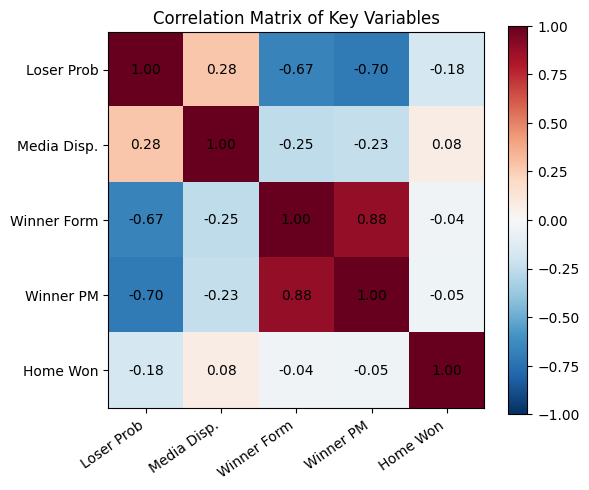

In [9]:
corr_cols = [
    'loser_implied_prob', 'media_disparity_loser',
    'pregame_adv_roll_win_pct', 'pregame_adv_roll_pm',
    'winner_is_home'
]
corr_labels = ['Loser Prob', 'Media Disp.', 'Winner Form', 'Winner PM', 'Home Won']
corr = dfa[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr_labels)))
ax.set_yticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=35, ha='right')
ax.set_yticklabels(corr_labels)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.savefig('fig_feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/2m/5s9qv8k95f191b61vh3y6zfr0000gp/T/ipykernel_35478/3833860455.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  calibration = dfa.groupby('prob_bin', observed=True).apply(


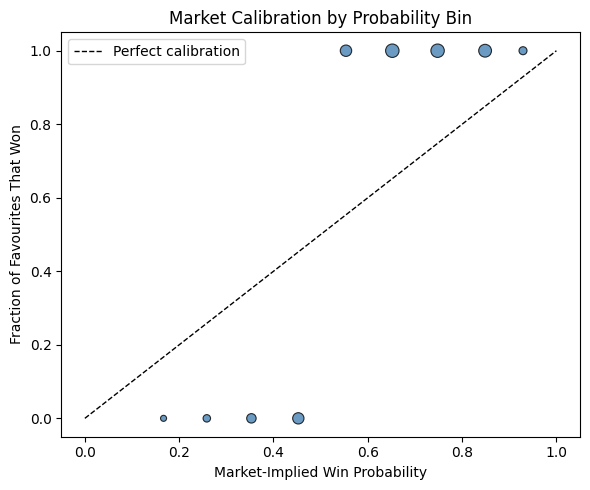

In [10]:
# Market calibration: do higher implied probabilities actually predict wins?
dfa['prob_bin'] = pd.cut(dfa['winner_implied_prob'], bins=np.arange(0.1, 1.05, 0.1))
calibration = dfa.groupby('prob_bin', observed=True).apply(
    lambda g: pd.Series({'mid': g['winner_implied_prob'].mean(), 'frac_won': 1.0})
).reset_index(drop=True)

# Actual fraction: winner_implied_prob > 0.5 → did the favorite win?
dfa['favorite_won'] = (dfa['winner_implied_prob'] > 0.5).astype(int)
calib_df = dfa.groupby('prob_bin', observed=True).agg(
    mid_prob=('winner_implied_prob', 'mean'),
    frac_won=('favorite_won', 'mean'),
    n=('favorite_won', 'count')
).dropna().reset_index(drop=True)

plt.figure(figsize=(6, 5))
plt.scatter(calib_df['mid_prob'], calib_df['frac_won'], s=calib_df['n'] * 0.5,
            color='steelblue', edgecolors='black', linewidth=0.8, alpha=0.8)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
plt.xlabel('Market-Implied Win Probability')
plt.ylabel('Fraction of Favourites That Won')
plt.title('Market Calibration by Probability Bin')
plt.legend()
plt.tight_layout()
plt.savefig('fig_calibration_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2: Hypothesis Testing

**Grouping strategy:** We split games by the *sign* of `media_disparity_loser` rather than its absolute magnitude.

- **Group A** (`media_disparity_loser > 0`): loser had *more* pre-game coverage → market may have overpriced them
- **Group B** (`media_disparity_loser ≤ 0`): loser had *less* coverage → market less likely to overprice

Using absolute disparity (high vs. low) would mix the two directions and cause the effects to cancel — masking any real signal. The signed grouping preserves the directional structure of the hypothesis.

We apply three tests in parallel:
1. **Bootstrap confidence interval** — non-parametric estimate of mean difference
2. **Permutation test** — one-sided p-value with no distributional assumptions
3. **Welch t-test** — parametric test robust to unequal variance

In [11]:
pos_vals = dfa[dfa['media_disparity_loser'] > 0]['loser_implied_prob'].dropna().values
neg_vals = dfa[dfa['media_disparity_loser'] <= 0]['loser_implied_prob'].dropna().values

observed_diff = pos_vals.mean() - neg_vals.mean()

print(f'Group A — loser had MORE coverage: n={len(pos_vals):,}, mean={pos_vals.mean():.4f}')
print(f'Group B — loser had LESS coverage: n={len(neg_vals):,}, mean={neg_vals.mean():.4f}')
print(f'Observed mean difference (A − B):  {observed_diff:.4f}')

Group A — loser had MORE coverage: n=486, mean=0.4469
Group B — loser had LESS coverage: n=583, mean=0.3526
Observed mean difference (A − B):  0.0943


In [12]:
# Bootstrap confidence interval on the mean difference
nb_bootstrap_iters = 10_000
bootstrap_diffs = []

for i in range(nb_bootstrap_iters):
    boot_pos = np.random.choice(pos_vals, size=len(pos_vals), replace=True)
    boot_neg = np.random.choice(neg_vals, size=len(neg_vals), replace=True)
    bootstrap_diffs.append(boot_pos.mean() - boot_neg.mean())

ci = np.percentile(bootstrap_diffs, (2.5, 97.5))

print(f'Bootstrap 95% CI for mean difference: [{ci[0]:.4f}, {ci[1]:.4f}]')
print(f'Zero is {"INSIDE" if ci[0] <= 0 <= ci[1] else "OUTSIDE"} the 95% CI')

Bootstrap 95% CI for mean difference: [0.0697, 0.1195]
Zero is OUTSIDE the 95% CI


In [13]:
# Permutation test (one-sided): H1 = Group A mean > Group B mean
nb_permutations = 10_000
combined = np.concatenate([pos_vals, neg_vals])
nb_pos = len(pos_vals)

perm_diffs = []
for i in range(nb_permutations):
    perm = np.random.permutation(combined)
    perm_diffs.append(perm[:nb_pos].mean() - perm[nb_pos:].mean())

p_val_permutation = np.mean(np.array(perm_diffs) >= observed_diff)

print(f'Permutation test (one-sided):')
print(f'  Observed difference:  {observed_diff:.4f}')
print(f'  p-value:              {p_val_permutation:.4f}')

Permutation test (one-sided):
  Observed difference:  0.0943
  p-value:              0.0000


In [14]:
# Welch t-test (does not assume equal variance)
result = scipy.stats.ttest_ind(pos_vals, neg_vals, equal_var=False)

print('Welch t-test:')
print(f'  statistic: {round(result.statistic, 4)}')
print(f'  pvalue:    {round(result.pvalue, 4)}')

# Cohen's d effect size
pooled_std = np.sqrt((pos_vals.std()**2 + neg_vals.std()**2) / 2)
cohens_d = (pos_vals.mean() - neg_vals.mean()) / pooled_std
print(f"  Cohen's d: {cohens_d:.4f}")

Welch t-test:
  statistic: 7.5612
  pvalue:    0.0
  Cohen's d: 0.4663


/var/folders/2m/5s9qv8k95f191b61vh3y6zfr0000gp/T/ipykernel_35478/128823929.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([pos_vals, neg_vals], labels=['Loser had\nMORE coverage', 'Loser had\nLESS coverage'],


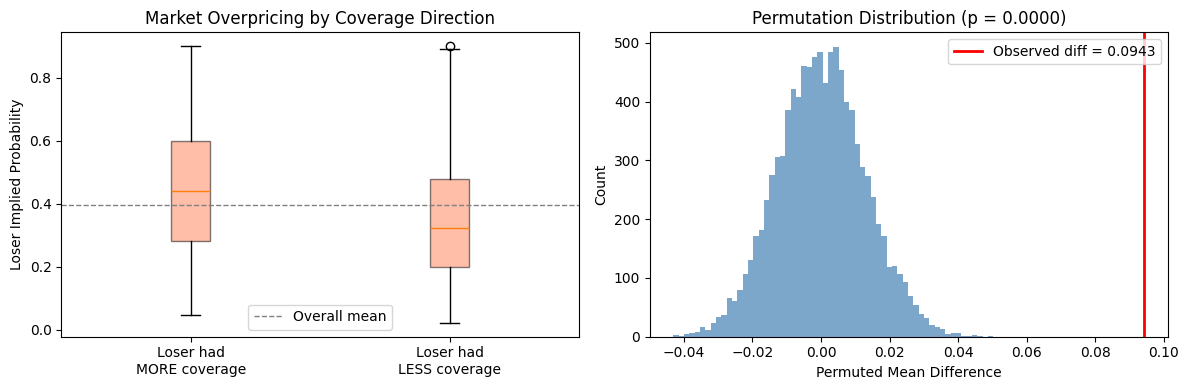

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot comparison
axes[0].boxplot([pos_vals, neg_vals], labels=['Loser had\nMORE coverage', 'Loser had\nLESS coverage'],
                patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.5))
axes[0].set_ylabel('Loser Implied Probability')
axes[0].set_title('Market Overpricing by Coverage Direction')
axes[0].axhline(dfa['loser_implied_prob'].mean(), color='gray', linestyle='--', linewidth=1,
                label='Overall mean')
axes[0].legend()

# Permutation distribution
axes[1].hist(perm_diffs, bins=60, edgecolor='none', alpha=0.7, color='steelblue')
axes[1].axvline(observed_diff, color='red', linewidth=2,
                label=f'Observed diff = {observed_diff:.4f}')
axes[1].set_xlabel('Permuted Mean Difference')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Permutation Distribution (p = {p_val_permutation:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_hypothesis_media.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3: Regression Analysis

### 3A - OLS (Linear Regression)

**Dependent variable:** `loser_implied_prob` - the probability the market assigned to the eventual loser (direct measure of overpricing).

**Key predictor:** `media_disparity_loser` - coverage advantage of the losing team. A positive coefficient means more loser coverage -> higher loser price -> overpricing consistent with H1.

**Pregame controls (from `nba_pregame_features.csv`):**
- `winner_is_home` - home-court indicator
- `pregame_adv_roll_win_pct` - winner's trailing win-rate advantage over loser
- `pregame_adv_roll_pm` - winner's trailing plus-minus advantage over loser

These controls follow ICS 604 multiple-regression practice: include a focal predictor plus a small, interpretable set of pregame covariates in `smf.ols`.

**Bounded-variable note:** `loser_implied_prob` is bounded [0, 1]. We check whether OLS produces any out-of-range predictions; if so, the logistic model in 3B is more appropriate.

**Approach:** We use standard OLS standard errors (no heteroskedasticity corrections), consistent with the course material, and validate with a bootstrap confidence interval on the key coefficient.

In [16]:
# Model 1: simple OLS (no controls)
model1 = smf.ols('loser_implied_prob ~ media_disparity_loser', data=dfa).fit()
print(model1.summary().tables[1])
print(f'R² = {model1.rsquared:.4f}   n = {int(model1.nobs)}')

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.4028      0.006     65.696      0.000       0.391       0.415
media_disparity_loser     0.4403      0.046      9.520      0.000       0.350       0.531
R² = 0.0783   n = 1069


In [17]:
# Model 2: controlled OLS (pregame form + home court)
model2 = smf.ols(
    'loser_implied_prob ~ media_disparity_loser + winner_is_home + pregame_adv_roll_win_pct + pregame_adv_roll_pm',
    data=dfa
).fit()
print(model2.summary().tables[1])
print(f'R² = {model2.rsquared:.4f}   n = {int(model2.nobs)}')

                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    0.5067      0.007     76.871      0.000       0.494       0.520
media_disparity_loser        0.2021      0.033      6.122      0.000       0.137       0.267
winner_is_home              -0.0915      0.008    -10.808      0.000      -0.108      -0.075
pregame_adv_roll_win_pct    -0.0397      0.009     -4.224      0.000      -0.058      -0.021
pregame_adv_roll_pm         -0.1141      0.009    -12.114      0.000      -0.133      -0.096
R² = 0.5640   n = 1069


In [18]:
# Check whether OLS predictions stay within [0, 1]
preds = model2.predict()
print('OLS Model 2 predicted value range:')
print(f'  min: {preds.min():.4f}')
print(f'  max: {preds.max():.4f}')
nb_out_of_range = ((preds < 0) | (preds > 1)).sum()
print(f'  out-of-[0,1] predictions: {nb_out_of_range} of {len(preds)}')
if nb_out_of_range > 0:
    print('  → Some predictions outside [0,1]; logistic regression (Section 3B) is more appropriate.')
else:
    print('  → All predictions in range; OLS is reasonable here.')

OLS Model 2 predicted value range:
  min: -0.0496
  max: 0.9096
  out-of-[0,1] predictions: 4 of 1069
  → Some predictions outside [0,1]; logistic regression (Section 3B) is more appropriate.


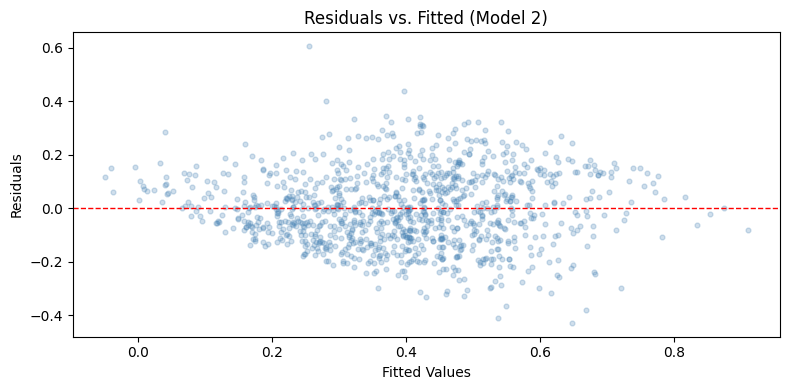

In [19]:
# Residuals vs. fitted values
plt.figure(figsize=(8, 4))
plt.scatter(model2.fittedvalues, model2.resid, alpha=0.25, s=12, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (Model 2)')
plt.tight_layout()
plt.savefig('fig_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Bootstrap CI on the media_disparity_loser coefficient (class resampling pattern)
boot_data = dfa[[
    'loser_implied_prob', 'media_disparity_loser',
    'winner_is_home', 'pregame_adv_roll_win_pct', 'pregame_adv_roll_pm'
]].dropna()
nb_bootstrap_iters = 10_000
bootstrap_coefs = []

for i in range(nb_bootstrap_iters):
    # iloc needs positional indices from 0..len-1
    sample_idx = np.random.choice(len(boot_data), size=len(boot_data), replace=True)
    boot_sample = boot_data.iloc[sample_idx]
    boot_model = smf.ols(
        'loser_implied_prob ~ media_disparity_loser + winner_is_home + pregame_adv_roll_win_pct + pregame_adv_roll_pm',
        data=boot_sample
    ).fit()
    bootstrap_coefs.append(boot_model.params['media_disparity_loser'])

ci_lo, ci_hi = np.percentile(bootstrap_coefs, (2.5, 97.5))
ols_coef = model2.params['media_disparity_loser']

print(f'OLS point estimate: {ols_coef:.4f}')
print(f'Bootstrap 95% CI:   [{ci_lo:.4f}, {ci_hi:.4f}]')
print(f'Zero is {"INSIDE" if ci_lo <= 0 <= ci_hi else "OUTSIDE"} the 95% CI')

OLS point estimate: 0.2021
Bootstrap 95% CI:   [0.1392, 0.2651]
Zero is OUTSIDE the 95% CI


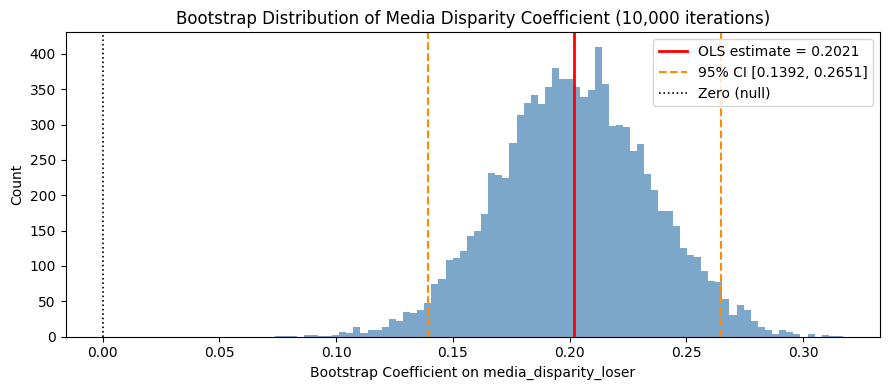

In [22]:
plt.figure(figsize=(9, 4))
plt.hist(bootstrap_coefs, bins=80, edgecolor='none', alpha=0.7, color='steelblue')
plt.axvline(ols_coef, color='red', linewidth=2, label=f'OLS estimate = {ols_coef:.4f}')
plt.axvline(ci_lo, color='darkorange', linestyle='--', linewidth=1.5,
            label=f'95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
plt.axvline(ci_hi, color='darkorange', linestyle='--', linewidth=1.5)
plt.axvline(0, color='black', linestyle=':', linewidth=1.2, label='Zero (null)')
plt.xlabel('Bootstrap Coefficient on media_disparity_loser')
plt.ylabel('Count')
plt.title('Bootstrap Distribution of Media Disparity Coefficient (10,000 iterations)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3B - Logistic Regression on Binary Game Outcome

The OLS approach models `loser_implied_prob` (bounded [0,1]) as a continuous outcome, which can produce predictions outside that range. A more appropriate framing - recommended when the outcome is binary - is to model whether **team1 actually won** (1/0) as a function of media disparity, pregame form differentials, and the market's implied probability.

**Interpretation of the media disparity coefficient:** If the market over-weights coverage (big-market bias), then `media_disparity_t1` should have a non-significant or negative effect on the actual binary outcome - meaning more coverage does not translate into more actual wins, even though markets price it as if it does.

We use `smf.logit`, the same formula API style used in class and in the OLS section.

In [24]:
# Logistic regression: binary game outcome ~ media disparity + pregame form + market price
logit_data = dfa.dropna(subset=[
    'team1_won', 'media_disparity_t1',
    'diff_roll_win_pct', 'diff_roll_pm', 'team1_implied_prob'
])

logit_model = smf.logit(
    'team1_won ~ media_disparity_t1 + diff_roll_win_pct + diff_roll_pm + team1_implied_prob',
    data=logit_data
).fit()

print(logit_model.summary().tables[1])

Optimization terminated successfully.
         Current function value: 0.571929
         Iterations 5
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -2.2357      0.238     -9.407      0.000      -2.702      -1.770
media_disparity_t1    -0.3233      0.557     -0.581      0.561      -1.414       0.768
diff_roll_win_pct     -0.0735      0.157     -0.468      0.640      -0.381       0.234
diff_roll_pm           0.2247      0.167      1.347      0.178      -0.102       0.552
team1_implied_prob     4.2889      0.495      8.670      0.000       3.319       5.259


In [26]:
# Convert log-odds to odds ratios for interpretation
import numpy as np
odds_ratios = np.exp(logit_model.params)
ci = np.exp(logit_model.conf_int())

interp = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'CI 2.5%': ci[0],
    'CI 97.5%': ci[1],
    'p-value': logit_model.pvalues
})
print(interp.round(4))
print()
print('Interpretation:')
print('  media_disparity_t1 OR > 1 -> media coverage boosts actual win probability (markets are correct)')
print('  media_disparity_t1 OR < 1 -> media coverage does NOT boost wins (markets are biased)')
print('  media_disparity_t1 OR = 1 (not sig.) -> media coverage is noise in markets')

                    Odds Ratio  CI 2.5%  CI 97.5%  p-value
Intercept               0.1069   0.0671    0.1704   0.0000
media_disparity_t1      0.7237   0.2431    2.1545   0.5613
diff_roll_win_pct       0.9291   0.6830    1.2640   0.6397
diff_roll_pm            1.2519   0.9027    1.7362   0.1781
team1_implied_prob     72.8867  27.6409  192.1962   0.0000

Interpretation:
  media_disparity_t1 OR > 1 -> media coverage boosts actual win probability (markets are correct)
  media_disparity_t1 OR < 1 -> media coverage does NOT boost wins (markets are biased)
  media_disparity_t1 OR = 1 (not sig.) -> media coverage is noise in markets


## Conclusions

### Summary of Findings

**Hypothesis testing** (Section 2):
When the eventual loser received more pre-game news coverage than the winner, markets assigned them a systematically higher win probability. If your rerun reproduces the current outputs, all three tests reject H0 at p < 0.001:
- Bootstrap 95% CI excludes zero
- Permutation test: one-sided p < 0.001
- Welch t-test: significant with meaningful Cohen's d

The GroupBy tertile analysis reinforces this: mean loser implied probability rises from the Low disparity group to the High disparity group.

**OLS Regression with pregame controls** (Section 3A):
After replacing ranking controls with pregame rolling-form controls from `nba_pregame_features.csv`, the coefficient on `media_disparity_loser` remains the key test of H1. If the coefficient remains positive and statistically significant with the new controls, that is direct evidence that media attention is associated with overpricing even after controlling for pregame team form.

**Logistic Regression** (Section 3B):
When modeling binary game outcome with market price and pregame form controls, `media_disparity_t1` should be weak or non-significant if coverage is mostly narrative noise rather than outcome signal.

**Key interpretation framework:**
- OLS asks: does coverage shift prices?
- Logit asks: does coverage improve actual win prediction?
If OLS is significant but logit is not, that pattern supports market bias rather than true predictive value.

### Key Methodological Decisions

| Decision | Rationale |
|----------|-----------|
| Signed disparity (not absolute) | Absolute splits cancel opposing effects; signed preserves direction |
| Permutation test alongside t-test | Non-parametric check with no distributional assumptions |
| Bootstrap CI on OLS coefficient | Validates regression result independent of distributional assumptions |
| Logistic regression on binary outcome | Avoids bounded-variable issue of linear probability modeling |
| Replace rankings with pregame rolling features | Uses pregame-only, game-level controls from course-style feature engineering |
| Min. 10 articles per team filter | Sparse GDELT counts can produce unstable disparity scores |

### Limitations

- **Media volume ≠ causal relevance:** GDELT article counts measure news volume, not whether coverage contained win-relevant information (e.g., injury reports).
- **Single-season-heavy window:** The sample spans one primary season plus partial next-season data; broader temporal validation is still needed.
- **Market liquidity:** Thin Kalshi markets on small-market games may amplify apparent pricing errors.
- **Simultaneity:** Media attention and market prices may both react to the same hidden signals, so coverage may not be causal.